In [1]:
# Import des librairies
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import sklearn

In [ ]:
# Chargement des données (X : variables explicatives, y : variable réponse)
X=pd.read_csv(r'/Users/marc-antoine/Desktop/3A/CS/Machine Learning B/TP 1/bardet_x.csv')
y=pd.read_csv(r'/Users/marc-antoine/Desktop/3A/CS/Machine Learning B/TP 1/bardet_y.csv')

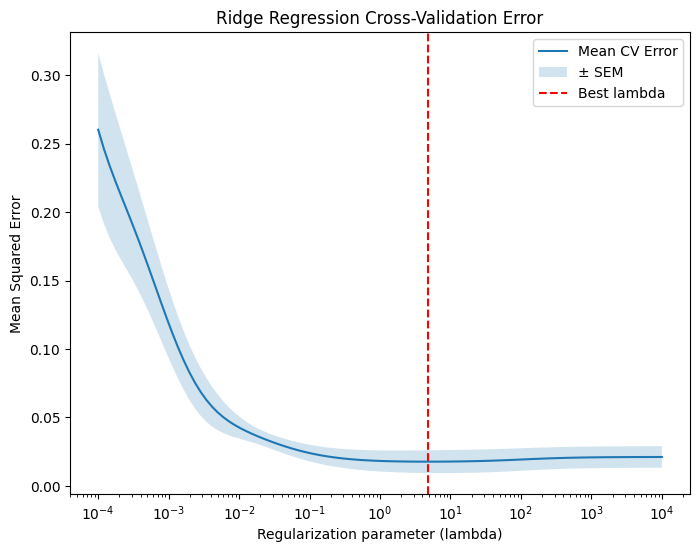

In [3]:
# Régression Ridge avec validation croisée
from sklearn import linear_model
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
lambdas = np.logspace(-4, 4, 100)
gridsearch = GridSearchCV(Ridge(),param_grid={'alpha':lambdas},cv=5,scoring='neg_mean_squared_error')
gridsearch.fit(X,y.values.ravel())
mse_mean = -gridsearch.cv_results_['mean_test_score']
mse_std = gridsearch.cv_results_['std_test_score']
n_folds = gridsearch.n_splits_
sem = mse_std / np.sqrt(n_folds)
plt.figure(figsize=(8,6))
plt.semilogx(lambdas, mse_mean, label='Erreur moyenne (CV)')
plt.fill_between(lambdas, mse_mean - sem, mse_mean + sem, alpha=0.2, label='± ESM')
plt.axvline(gridsearch.best_params_['alpha'], color='r', linestyle='--', label='Meilleur lambda')
plt.xlabel('Paramètre de régularisation (lambda)')
plt.ylabel('Erreur quadratique moyenne')
plt.title('Erreur de validation croisée - Régression Ridge')
plt.legend()
plt.show()

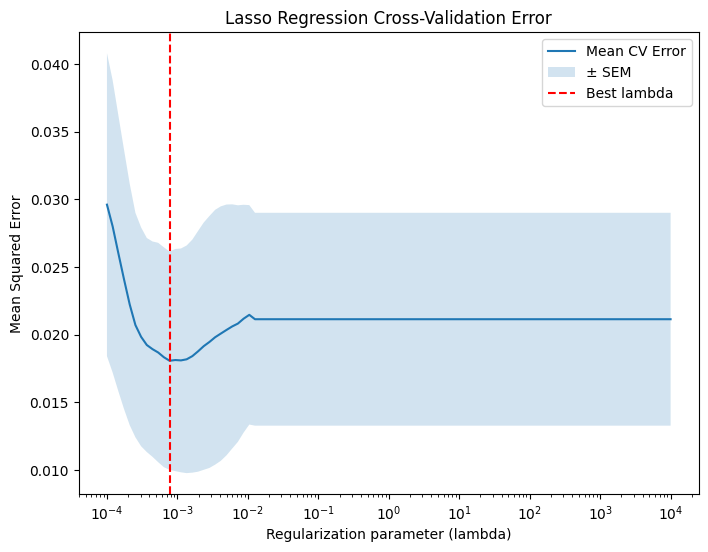

In [4]:
# Même chose avec la régression Lasso
from sklearn.linear_model import Lasso
gridsearch_lasso = GridSearchCV(Lasso(max_iter=10000),param_grid={'alpha':lambdas},cv=5,scoring='neg_mean_squared_error')
gridsearch_lasso.fit(X,y.values.ravel())
mse_mean_lasso = -gridsearch_lasso.cv_results_['mean_test_score']
mse_std_lasso = gridsearch_lasso.cv_results_['std_test_score']
n_folds_lasso = gridsearch_lasso.n_splits_
sem_lasso = mse_std_lasso / np.sqrt(n_folds_lasso)
plt.figure(figsize=(8,6))
plt.semilogx(lambdas, mse_mean_lasso, label='Erreur moyenne (CV)')
plt.fill_between(lambdas, mse_mean_lasso - sem_lasso, mse_mean_lasso + sem_lasso, alpha=0.2, label='± ESM')
plt.axvline(gridsearch_lasso.best_params_['alpha'], color='r', linestyle='--', label='Meilleur lambda')
plt.xlabel('Paramètre de régularisation (lambda)')
plt.ylabel('Erreur quadratique moyenne')
plt.title('Erreur de validation croisée - Régression Lasso')
plt.legend()
plt.show()

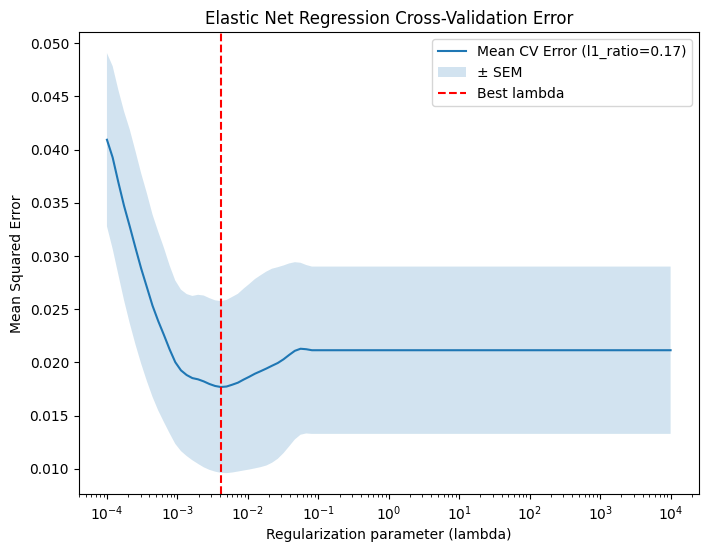

In [5]:
# Même chose avec la régression Elastic Net
from sklearn.linear_model import ElasticNet
l1_ratios = np.linspace(0.01, 1, 20)
gridsearch_elastic = GridSearchCV(
    ElasticNet(max_iter=10000),
    param_grid={'alpha': lambdas, 'l1_ratio': l1_ratios},
    cv=5,
    scoring='neg_mean_squared_error'
)
gridsearch_elastic.fit(X, y.values.ravel())

mse_grid_elastic = -gridsearch_elastic.cv_results_['mean_test_score'].reshape(len(lambdas), len(l1_ratios))
std_grid_elastic = gridsearch_elastic.cv_results_['std_test_score'].reshape(len(lambdas), len(l1_ratios))

best_alpha = gridsearch_elastic.best_params_['alpha']
best_l1 = gridsearch_elastic.best_params_['l1_ratio']
best_l1_idx = np.argmin(np.abs(l1_ratios - best_l1))

mse_mean_elastic = mse_grid_elastic[:, best_l1_idx]
sem_elastic = std_grid_elastic[:, best_l1_idx] / np.sqrt(gridsearch_elastic.n_splits_)

plt.figure(figsize=(8,6))
plt.semilogx(lambdas, mse_mean_elastic, label=f'Erreur moyenne (l1_ratio={best_l1:.2f})')
plt.fill_between(lambdas, mse_mean_elastic - sem_elastic, mse_mean_elastic + sem_elastic, alpha=0.2, label='± ESM')
plt.axvline(best_alpha, color='r', linestyle='--', label='Meilleur lambda')
plt.xlabel('Paramètre de régularisation (lambda)')
plt.ylabel('Erreur quadratique moyenne')
plt.title('Erreur de validation croisée - Régression Elastic Net')
plt.legend()
plt.show()

In [ ]:
# Visualisation des groupes de variables (gènes) sélectionnés par elastic net
best_elastic = gridsearch_elastic.best_estimator_
coefs = best_elastic.coef_
coefs_grouped = coefs.reshape(20, 5)

vmax = np.abs(coefs).max()
plt.figure(figsize=(10, 6))
plt.imshow(coefs_grouped, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(label='Coefficient')
plt.xlabel('Fonction de base B-spline (1 à 5)')
plt.ylabel('Gène candidat')
plt.yticks(range(20), [f'Gène {i+1}' for i in range(20)])
plt.xticks(range(5), [f'{j+1}' for j in range(5)])
plt.title('Coefficients Elastic Net par gène et fonction de base')
plt.show()

n_nonzero_per_gene = np.sum(coefs_grouped != 0, axis=1)
colors = ['#2c7fb8' if n == 5 else '#d9d9d9' if n == 0 else '#f16913' for n in n_nonzero_per_gene]

plt.figure(figsize=(10, 6))
plt.bar(range(1, 21), n_nonzero_per_gene, color=colors)
plt.axhline(5, color='k', linestyle='--', linewidth=1, label='Groupe complet (5/5)')
plt.xlabel('Gène candidat')
plt.ylabel('Nombre de coefficients non nuls (sur 5)')
plt.xticks(range(1, 21))
plt.title('Sélection au niveau du gène - elastic net (bleu = groupe complet, orange = sélection partielle, gris = non sélectionné)')
plt.legend()
plt.show()

print(f"Gènes non sélectionnés (0/5) : {np.sum(n_nonzero_per_gene == 0)}")
print(f"Gènes partiellement sélectionnés (1 à 4 sur 5) : {np.sum((n_nonzero_per_gene > 0) & (n_nonzero_per_gene < 5))}")
print(f"Gènes entièrement sélectionnés (5/5) : {np.sum(n_nonzero_per_gene == 5)}")

In [ ]:
# Group Lasso (pip install group-lasso), avec 20 groupes de taille pg=5
from group_lasso import GroupLasso
groups = np.repeat(np.arange(20), 5)

lambdas_group = np.logspace(-4, 2, 100)
gl = GroupLasso(groups=groups, l1_reg=0, n_iter=10000, supress_warning=True)

gridsearch_group = GridSearchCV(gl, param_grid={'group_reg': lambdas_group}, cv=5, scoring='neg_mean_squared_error')
gridsearch_group.fit(X, y.values.ravel())

mse_mean_group = -gridsearch_group.cv_results_['mean_test_score']
mse_std_group = gridsearch_group.cv_results_['std_test_score']
sem_group = mse_std_group / np.sqrt(gridsearch_group.n_splits_)

plt.figure(figsize=(8,6))
plt.semilogx(lambdas_group, mse_mean_group, label='Erreur moyenne (CV)')
plt.fill_between(lambdas_group, mse_mean_group - sem_group, mse_mean_group + sem_group, alpha=0.2, label='± ESM')
plt.axvline(gridsearch_group.best_params_['group_reg'], color='r', linestyle='--', label='Meilleur lambda')
plt.xlabel('Paramètre de régularisation (lambda)')
plt.ylabel('Erreur quadratique moyenne')
plt.title('Erreur de validation croisée - Group Lasso')
plt.legend()
plt.show()

best_group_model = gridsearch_group.best_estimator_
coefs_group = best_group_model.coef_.ravel()
coefs_group_grouped = coefs_group.reshape(20, 5)
genes_selected_group = np.where(np.any(coefs_group_grouped != 0, axis=1))[0] + 1
print(f"Gènes candidats sélectionnés par group Lasso : {genes_selected_group}")
print(f"Nombre de gènes sélectionnés : {len(genes_selected_group)} / 20")

vmax = np.abs(coefs_group).max()
plt.figure(figsize=(10, 6))
plt.imshow(coefs_group_grouped, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(label='Coefficient')
plt.xlabel('Fonction de base B-spline (1 à 5)')
plt.ylabel('Gène candidat')
plt.yticks(range(20), [f'Gène {i+1}' for i in range(20)])
plt.xticks(range(5), [f'{j+1}' for j in range(5)])
plt.title('Coefficients Group Lasso par gène et fonction de base')
plt.show()

n_nonzero_per_gene_group = np.sum(coefs_group_grouped != 0, axis=1)
colors_group = ['#2c7fb8' if n == 5 else '#d9d9d9' if n == 0 else '#f16913' for n in n_nonzero_per_gene_group]

plt.figure(figsize=(10, 6))
plt.bar(range(1, 21), n_nonzero_per_gene_group, color=colors_group)
plt.axhline(5, color='k', linestyle='--', linewidth=1, label='Groupe complet (5/5)')
plt.xlabel('Gène candidat')
plt.ylabel('Nombre de coefficients non nuls (sur 5)')
plt.xticks(range(1, 21))
plt.title('Sélection au niveau du gène - group Lasso (tout ou rien par groupe, aucune barre orange attendue)')
plt.legend()
plt.show()

In [8]:
# Comparaison des 4 modèles (Ridge, Lasso, Elastic Net, Group Lasso) en MSE moyen et erreur standard
mse_means = [mse_mean[np.argmin(mse_mean)], mse_mean_lasso[np.argmin(mse_mean_lasso)], mse_mean_elastic[np.argmin(mse_mean_elastic)], mse_mean_group[np.argmin(mse_mean_group)]]
sem_means = [sem[np.argmin(mse_mean)], sem_lasso[np.argmin(mse_mean_lasso)], sem_elastic[np.argmin(mse_mean_elastic)], sem_group[np.argmin(mse_mean_group)]]
print("Comparaison des modèles :")
for model_name, mse_val, sem_val in zip(['Ridge', 'Lasso', 'Elastic Net', 'Group Lasso'], mse_means, sem_means):
    print(f"{model_name} : MSE moyen = {mse_val:.4f}, Erreur standard = {sem_val:.4f}")

Model comparison:
Ridge: Mean MSE = 0.0177, Standard error = 0.0083
Lasso: Mean MSE = 0.0181, Standard error = 0.0081
Elastic Net: Mean MSE = 0.0177, Standard error = 0.0081
Group Lasso: Mean MSE = 0.0182, Standard error = 0.0082


## Bizarre : on a un moins bon score. Mais la sélection par groupe a permis la sélection de cinq gènes. On retrain maintenant sur seulement ces cinq gènes.

In [13]:
# Sélection des colonnes (5 bases de splines) correspondant aux gènes retenus par le group lasso
gene_idx0 = genes_selected_group - 1
cols_selected = np.concatenate([np.arange(g*5, g*5 + 5) for g in gene_idx0])
X_selected = X.iloc[:, cols_selected]
X_selected

,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,...,V26,V27,V28,V29,V30,V51,V52,V53,V54,V55
0,0.005499,0.607157,0.382617,4.727791e-03,0.000000,0.009054,0.792591,0.197103,0.001252,0.000000,...,2.139697e-01,0.721100,0.055663,0.000000,0.000000e+00,0.103551,0.550802,0.343346,0.000000,0.000000
1,0.000000,0.377704,0.550897,7.086559e-02,0.000534,0.000000,0.594899,0.375943,0.028954,0.000205,...,8.020924e-07,0.779632,0.218306,0.002061,0.000000e+00,0.249781,0.536948,0.189325,0.000000,0.000000
2,0.037456,0.686292,0.276093,1.592218e-04,0.000000,0.393120,0.541414,0.030524,0.000000,0.000000,...,1.273081e-02,0.837754,0.149415,0.000101,0.000000e+00,0.053253,0.514079,0.432423,0.000000,0.000000
3,0.001784,0.570744,0.418535,8.937295e-03,0.000000,0.000000,0.566872,0.395820,0.036904,0.000404,...,4.709262e-04,0.801117,0.197333,0.001080,0.000000e+00,0.092592,0.545923,0.359828,0.000000,0.000000
4,0.062617,0.700933,0.236450,7.950574e-07,0.000000,0.000000,0.505165,0.434944,0.058601,0.001289,...,0.000000e+00,0.767155,0.230018,0.002827,6.899553e-08,0.148206,0.559632,0.286003,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.455751,0.413241,0.037122,0.000000e+00,0.000000,0.119669,0.785955,0.094369,0.000000,0.000000,...,0.000000e+00,0.694512,0.294771,0.010668,4.896294e-05,0.000000,0.030075,0.395024,0.471760,0.103141
116,0.452250,0.107421,0.003204,0.000000e+00,0.000000,0.449872,0.465493,0.021914,0.000000,0.000000,...,4.093883e-01,0.494197,0.021951,0.000000,0.000000e+00,0.000000,0.028739,0.386393,0.476368,0.108499
117,0.323889,0.570323,0.080057,0.000000e+00,0.000000,0.532248,0.260108,0.007140,0.000000,0.000000,...,1.423046e-01,0.781680,0.073682,0.000000,0.000000e+00,0.000000,0.002028,0.086726,0.429626,0.481619
118,0.022490,0.665720,0.311016,7.737842e-04,0.000000,0.070957,0.809552,0.119476,0.000014,0.000000,...,1.776616e-02,0.840906,0.141278,0.000049,0.000000e+00,0.049091,0.508772,0.441963,0.000000,0.000000


Ridge on selected variables: Best lambda = 0.008697490026177835, Mean MSE = 0.0125, Standard error = 0.0018


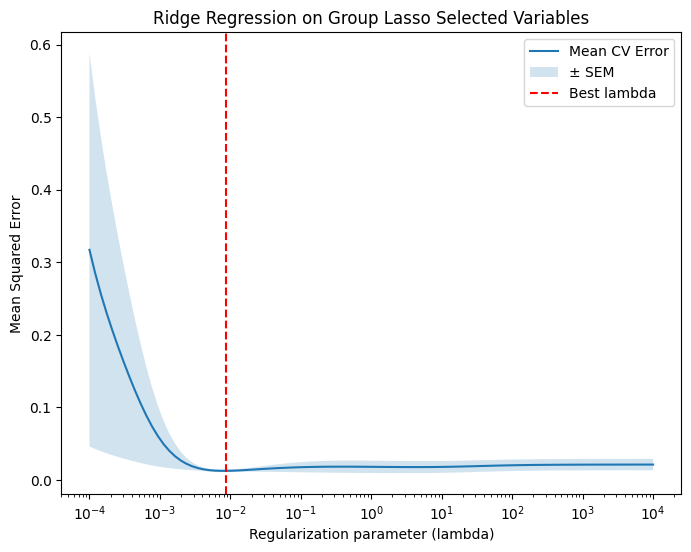

In [16]:
# Ridge sur les variables sélectionnées par le group lasso, pour comparer la performance (MSE) avec le group lasso seul
gridsearch_selected_ridge = GridSearchCV(Ridge(), param_grid={'alpha': lambdas}, cv=5, scoring='neg_mean_squared_error')
gridsearch_selected_ridge.fit(X_selected, y.values.ravel())
mse_mean_selected_ridge = -gridsearch_selected_ridge.cv_results_['mean_test_score']
mse_std_selected_ridge = gridsearch_selected_ridge.cv_results_['std_test_score']
sem_selected_ridge = mse_std_selected_ridge / np.sqrt(gridsearch_selected_ridge.n_splits_)
print(f"Ridge sur variables sélectionnées : Meilleur lambda = {gridsearch_selected_ridge.best_params_['alpha']}, MSE moyen = {mse_mean_selected_ridge[np.argmin(mse_mean_selected_ridge)]:.4f}, Erreur standard = {sem_selected_ridge[np.argmin(mse_mean_selected_ridge)]:.4f}")
plt.figure(figsize=(8,6))
plt.semilogx(lambdas, mse_mean_selected_ridge, label='Erreur moyenne (CV)')
plt.fill_between(lambdas, mse_mean_selected_ridge - sem_selected_ridge, mse_mean_selected_ridge + sem_selected_ridge, alpha=0.2, label='± ESM')
plt.axvline(gridsearch_selected_ridge.best_params_['alpha'], color='r', linestyle='--', label='Meilleur lambda')
plt.xlabel('Paramètre de régularisation (lambda)')
plt.ylabel('Erreur quadratique moyenne')
plt.title('Régression Ridge sur les variables sélectionnées par Group Lasso')
plt.legend()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.745688e-02, tolerance: 2.177e-04
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.842081e-01, tolerance: 1.163e-04
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number o

Best lambda for Lasso on selected variables: 6.483534286054727e-05
Mean CV Error for Lasso on selected variables: [0.13293698 0.13254018 0.13213829 0.13172993 0.13131754 0.13089795
 0.13047346 0.13004512 0.12961063 0.12917068 0.12872476 0.12827652
 0.12782385 0.12736439 0.12690128 0.12643456 0.1259652  0.12549069
 0.12501295 0.12453244 0.12404942 0.12356647 0.12308011 0.12259009
 0.12210367 0.12161734 0.12112751 0.12051122 0.11977808 0.11903691
 0.11828726 0.11753461 0.11677776 0.11601487 0.11524474 0.11447648
 0.11370188 0.11292329 0.11214689 0.11136695 0.11058684 0.10980742
 0.10903051 0.10825399 0.10748404 0.10671526 0.10595445 0.10519955
 0.10445477 0.1037173  0.10299248 0.10228184 0.10158419 0.10090298
 0.10024309 0.09959875 0.09896899 0.09834108 0.09774259 0.09717438
 0.09663647 0.09613806 0.09567572 0.0952563  0.0948837  0.09455731
 0.09428749 0.09407277 0.09391991 0.0938346  0.09381908 0.09388194
 0.09402818 0.09426114 0.09458991 0.09501879 0.09555744 0.09621212
 0.09699275 0.0

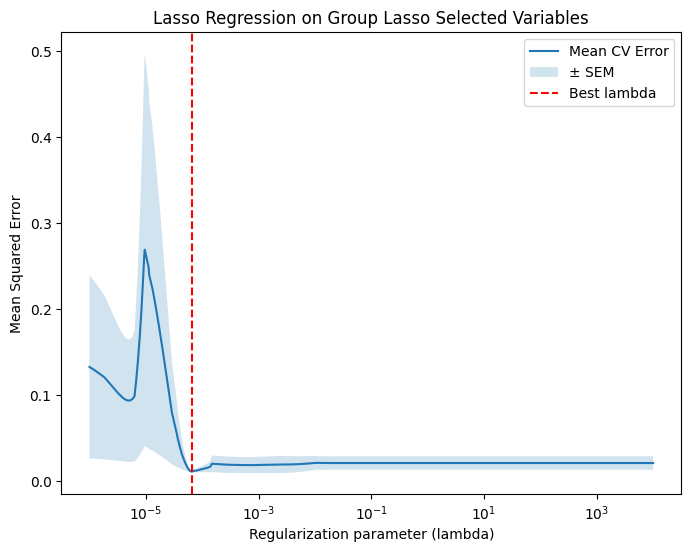

In [17]:
# Même chose avec Lasso sur les variables sélectionnées par le group lasso
lambdas=np.logspace(-6, 4, 1000)
gridsearch_selected_lasso = GridSearchCV(Lasso(max_iter=10000), param_grid={'alpha': lambdas}, cv=5, scoring='neg_mean_squared_error')
gridsearch_selected_lasso.fit(X_selected, y.values.ravel())
mse_mean_selected_lasso = -gridsearch_selected_lasso.cv_results_['mean_test_score']
mse_std_selected_lasso = gridsearch_selected_lasso.cv_results_['std_test_score']
sem_selected_lasso = mse_std_selected_lasso / np.sqrt(gridsearch_selected_lasso.n_splits_)
print(f"Meilleur lambda pour Lasso sur variables sélectionnées : {gridsearch_selected_lasso.best_params_['alpha']}")
print(f"Erreur moyenne de CV pour Lasso sur variables sélectionnées : {mse_mean_selected_lasso}")
print(f"Écart-type pour Lasso sur variables sélectionnées : {mse_std_selected_lasso}")
plt.figure(figsize=(8,6))
plt.semilogx(lambdas, mse_mean_selected_lasso, label='Erreur moyenne (CV)')
plt.fill_between(lambdas, mse_mean_selected_lasso - sem_selected_lasso, mse_mean_selected_lasso + sem_selected_lasso, alpha=0.2, label='± ESM')
plt.axvline(gridsearch_selected_lasso.best_params_['alpha'], color='r', linestyle='--', label='Meilleur lambda')
plt.xlabel('Paramètre de régularisation (lambda)')
plt.ylabel('Erreur quadratique moyenne')
plt.title('Régression Lasso sur les variables sélectionnées par Group Lasso')
plt.legend()
plt.show()

In [18]:
# Comparaison des deux MSE, et par rapport au MSE du group lasso seul
best_mse_ridge_selected = mse_mean_selected_ridge[np.argmin(mse_mean_selected_ridge)]
best_mse_lasso_selected = mse_mean_selected_lasso[np.argmin(mse_mean_selected_lasso)]
best_mse_group_lasso = mse_mean_group[np.argmin(mse_mean_group)]
print(f"Meilleur MSE pour Ridge sur variables sélectionnées : {best_mse_ridge_selected:.4f}")
print(f"Meilleur MSE pour Lasso sur variables sélectionnées : {best_mse_lasso_selected:.4f}")
print(f"Meilleur MSE pour Group Lasso : {best_mse_group_lasso:.4f}")

Best MSE for Ridge on selected variables: 0.0125
Best MSE for Lasso on selected variables: 0.0113
Best MSE for Group Lasso: 0.0182


In [20]:
# Quelle variable est sélectionnée par lasso ici ?
print(f"Variables sélectionnées par Lasso: {X_selected.columns[gridsearch_selected_lasso.best_estimator_.coef_ != 0].tolist()}")
print(f"Nombre de variables sélectionnées par Lasso: {np.sum(gridsearch_selected_lasso.best_estimator_.coef_ != 0)}")

Variables sélectionnées par Lasso: ['V11', 'V12', 'V14', 'V16', 'V18', 'V22', 'V23', 'V24', 'V26', 'V28', 'V29', 'V30', 'V51', 'V52', 'V53', 'V54', 'V55']
Nombre de variables sélectionnées par Lasso: 17


## Comparaison avec PCA

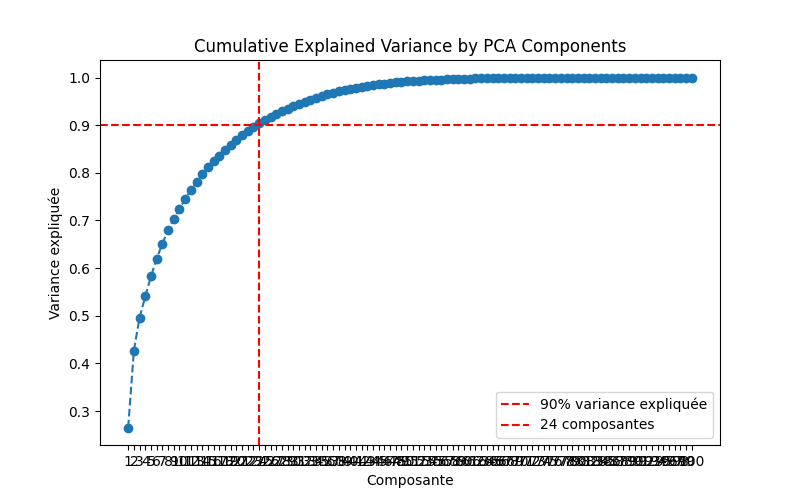

In [32]:
# On vérifie que les résultats sont cohérents avec une ACP via la méthode du coude
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X)
variance_ratio = pca.explained_variance_ratio_.cumsum()
n_components_90 = np.argmax(variance_ratio >= 0.9) + 1
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(variance_ratio) + 1), variance_ratio, 
         marker='o', linestyle='--')
plt.xlabel('Composante')
plt.ylabel('Variance expliquée')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% variance expliquée')
plt.axvline(x=n_components_90, color='r', linestyle='--', label=f'{n_components_90} composantes')
plt.title("Variance expliquée cumulée par les composantes de l'ACP")
plt.xticks(range(1, len(variance_ratio) + 1))
plt.legend()
plt.show()